In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bambi as bmb
import arviz as az

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

random_seed = 1234

## Introduction

This analysis investigates whether interventions influence hotel guests' decisions to reuse their towels. The dataset combines results from several randomized case-control studies in which guests were either given a standard environmental message (control intervention) or a message describing the towel-reuse behaviour of other guests (social-norm intervention). Following [Scheibehenne et al. (2016)](https://journals.sagepub.com/doi/10.1177/0956797616644081), we combine the evidence from these studies using a statistical model to estimate the overall intervention effect and assess the uncertainty around it.

### Data preparation

The data are read from the CSV file and the counts of **yes** and **no** responses are extracted for the control and social norm groups across the 7 studies. The total number of participants is then calculated for each group and study. The two groups are combined into one dataset, and the variables are converted to appropriate data types for use with **Bambi**.

In [169]:
# read in data
data_file = "towelData.csv"
data = pd.read_csv(data_file, sep=';', encoding='latin1')
count = data.iloc[:, -1] # get the last column with numbers or yes/no

# count has the number of yes and no for control and social norm groups
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)])

social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)])

study = np.arange(1,len(control_yes)+1) # 7 diferent studies

control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

combined_data = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types - important for bambi that they are correctly set 
# can give errors otherwise
combined_data['reuse'] = combined_data['reuse'].astype(int)
combined_data['total'] = combined_data['total'].astype(int)
combined_data['group'] = combined_data['group'].astype('category')
combined_data['study'] = combined_data['study'].astype('category')
#combined_data

In [170]:
# We define these functions because this plot is going to be repeated below.

def plot_prior_predictive(df, prior, axes, title=''):
    total = df["total"].values
    reuse = df["reuse"].values

    for idx, ax in enumerate(axes.ravel()):
        if idx == 0: ax.set_title(title)
        pps = prior.sel({"__obs__":idx})
        t = total[idx]
        r = reuse[idx]
        hist = ax.hist(np.array(pps[0])/t, bins=25, color="#ADD8E6")
        ax.axvline(r / t, color='red', lw=2)
        ax.set_yticks([])
        ax.tick_params(labelsize=12)


def data_summary(data,sample=("chain", "draw")):
    # Collapse chain and draw dimensions
    p = data.stack(sample=sample)

    # Quantiles over posterior samples
    summary = pd.DataFrame({
        "mean": p.mean(dim="sample").values,
        "median": p.median(dim="sample").values,
        "lower_90": p.quantile(0.05, dim="sample").values,
        "upper_90": p.quantile(0.95, dim="sample").values
    })
    return summary

### Initial group model

The first step is to analyze the probability of towel reuse in the both groups **(control/social)** using a binomial model. The intercept (`1`) estimates the overall probability of reuse, while `(1|study)` allows the baseline reuse probability to vary between studies. This accounts for differences between the 7 studies. The intervention variable is found in the variable **group** and is added to the equation as `(1|group)`.

**Model specification:**

$$
p(\text{reuse}, \text{total}) = \alpha + \beta_1 \cdot \text{study} + \beta_2 \cdot \text{group}, \quad \forall i = 1,..,n \quad \text{where } p = \operatorname{logit}.
$$

This is done in bambi with the following syntax: 

In [39]:
model = bmb.Model("p(reuse, total) ~ 1 + (1|study) + (1|group)", combined_data , family="binomial")
model
# print("###----Model for Control group:")
# print(model_control, end='\n\n')
# print("###----Model for Social group:")
# print(model_social)

       Formula: p(reuse, total) ~ 1 + (1|study) + (1|group)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))
            1|group ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))

### Fitting the models

The `.fit()` function runs the Bayesian model and estimates the model parameters using the data. We are especially interested in the **divergence** number which occurs when the MCMC sampler has difficulty exploring part of the model's posterior distribution. This means that some sampled values may not accurately represent the true posterior.

In [171]:
idata = model.fit(random_seed=random_seed)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 34 seconds.
There were 12 divergences after tuning. Increase `target_accept` or reparameterize.


### Prior predictive check

The results above are not satisfactory. In order to improve our models, we first visualise the different prior distributions and try to make appropriate adjustments.

The `prior_predictive()` function generates simulated data from the model's **prior distributions**, before using the observed data. This allows us to check whether the chosen priors produce reasonable predictions. The simulated values of `p(reuse, total)` are then extracted from the prior predictive distribution and passed to `plot_prior_predictive()`. The plot compares the **prior predictions** with the observed group data.

Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


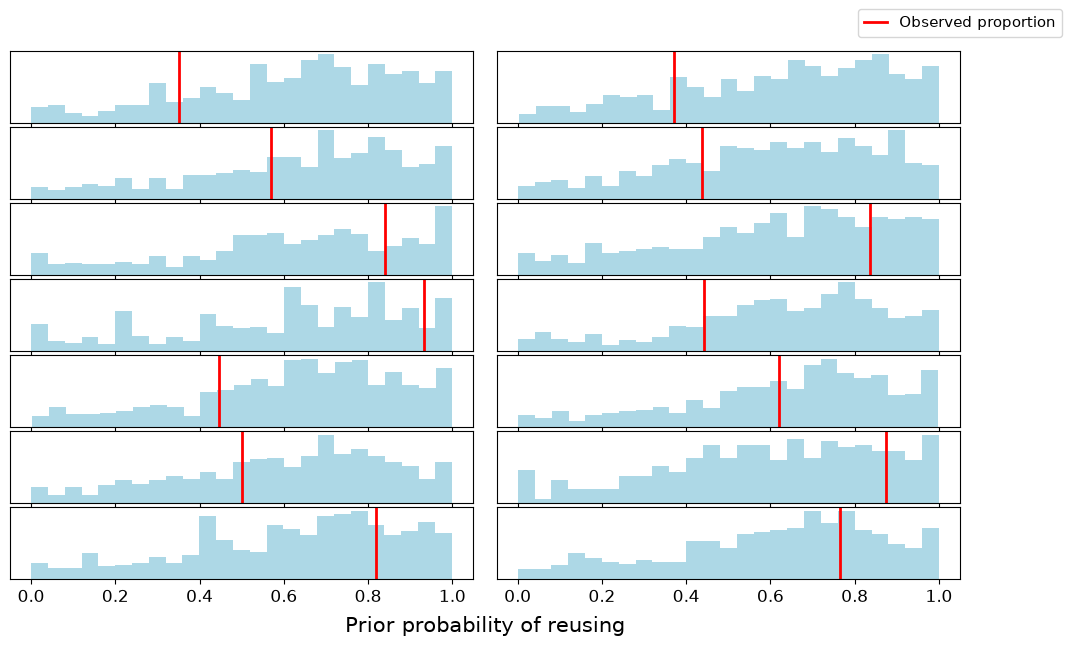

In [172]:
prior_dist = model.prior_predictive()
prior_samples = prior_dist.prior_predictive["p(reuse, total)"]

fig, axes = plt.subplots(7, 2, figsize=(10, 7), sharex="col")
plot_prior_predictive(combined_data, prior_samples, axes)
fig.subplots_adjust(left=0.025, right=0.975, hspace=0.05, wspace=0.05, bottom=0.125)
fig.legend(
    handles=[Line2D([0], [0], label="Observed proportion", color='red', linewidth=2)],
    handlelength=1.5,
    handletextpad=0.8,
    borderaxespad=0,
    frameon=True,
    fontsize=11, 
    bbox_to_anchor=(0.975, 0.92),
    loc="center"
);
fig.text(0.5, 0.05, "Prior probability of reusing", fontsize=15, ha="center", va="baseline");

The prior distributions are too spread out and are mostly focused on the tails for both cases. This implies that we need to reduce the variances for our distribution and pass this on to the new models.

Looking at the data, we can move our intercept to be around 0.6 since the reuse rate is mostly focused around this point.

In [173]:
priors = {"Intercept": bmb.Prior("Normal", mu=0.6, sigma=.4), 
          "group":   bmb.Prior("Normal", mu=0, sigma=1.0),
          "1|study":   bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=1.5))
          }
model = bmb.Model("p(reuse, total) ~ 1 + (1|study) + group", combined_data , family="binomial", priors = priors)
#model

Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


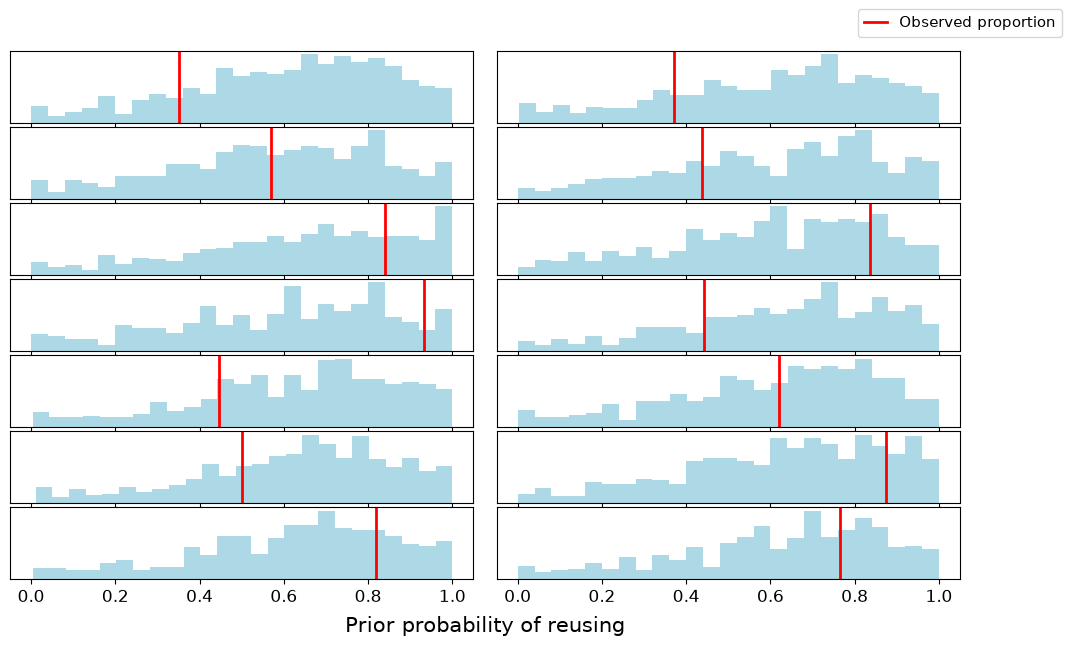

In [174]:
model.build() #The model has to be built again after remaking the priors.
prior_dist = model.prior_predictive()
prior_samples = prior_dist.prior_predictive["p(reuse, total)"]

fig, axes = plt.subplots(7, 2, figsize=(10, 7), sharex="col")
plot_prior_predictive(combined_data, prior_samples, axes)
fig.subplots_adjust(left=0.025, right=0.975, hspace=0.05, wspace=0.05, bottom=0.125)
fig.legend(
    handles=[Line2D([0], [0], label="Observed proportion", color='red', linewidth=2)],
    handlelength=1.5,
    handletextpad=0.8,
    borderaxespad=0,
    frameon=True,
    fontsize=11, 
    bbox_to_anchor=(0.975, 0.92),
    loc="center"
);
fig.text(0.5, 0.05, "Prior probability of reusing", fontsize=15, ha="center", va="baseline");

The prior distributions are looking much better. The next cell checks how the porsterior fits the data by checking divergences as explained before.

In [175]:
idata = model.fit(random_seed=random_seed, target_accept = 0.90)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 39 seconds.


### Comparing observed reuse proportions with posterior estimates

We use `model.predict()` to generate posterior predictions for the study-specific reuse probability `p`. We then pass these posterior samples to `data_summary()` to calculate summary statistics such as the posterior mean and the 90% credible interval.

In the plots below, each row corresponds to a datapoint:

- The **red horizontal line** shows the 90% credible interval for the posterior distribution of the reuse probability.
- The **red circle** shows the posterior mean of the reuse probability.
- The **blue `x`** shows the observed reuse proportion, calculated as `reuse / total`.

Thus, the plot compares the reuse proportion observed in each study with the reuse probability estimated by the hierarchical Bayesian model. We observed that the posterior distribution fits most of the data with an exception of two.

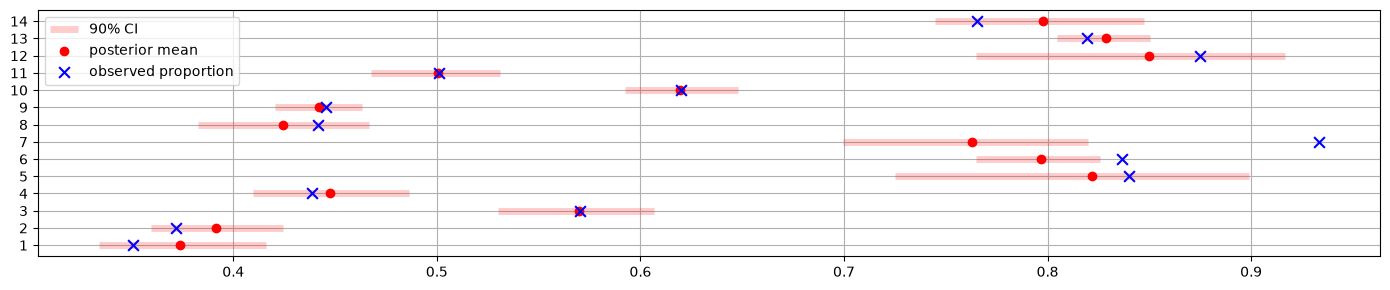

In [176]:
model.predict(idata)
summary = data_summary(idata.posterior["p"])

plt.figure(figsize=(14, 3))
y   = np.arange(1,len(summary)+1)
obs = combined_data['reuse']/combined_data['total']

plt.hlines(y, summary["lower_90"], summary["upper_90"], linewidth=5, alpha = 0.2, color='red', label='90% CI')
plt.scatter(summary["median"], y, marker="o", zorder=3, color='red', label = 'posterior mean')
plt.scatter(obs, y, marker="x", s=60, zorder=4, color='blue', label = 'observed proportion')

plt.yticks(y)
#plt.ylabel(combined_data["study"])
plt.xlabel("")
plt.title('')
plt.grid(True)
plt.legend(loc='best')
    
plt.tight_layout()
plt.show()

### Test Hypothesis and Bayesian Testing

To test the effectiveness of the descriptive social-norm or control intervention, we consider its positive effect $\beta_1 > 0$. Therefore, the null hypothesis is $H_0: \beta_1 \leq 0$, while the alternative hypothesis is $H_1: \beta_1 > 0$. The null hypothesis states that the intervention does not have a positive effect, whereas the alternative hypothesis states that the intervention increases towel reuse. 

We calculate the intervention effect by looking at the **distriburion** of this parameter given by the model. After fitting the Bayesian hierarchical model, we obtain a large number of posterior draws of $\beta_1$. For each posterior draw of this parameter, we calculate the Bayesian p-value as the simple arithmatic mean:

$$ p = P(\beta_1 \leq 0\mid\text{data}) \approx \frac{1}{n} \sum I_{\beta_1 \leq 0}.$$

P(beta1 <= 0 | data) = 0.004


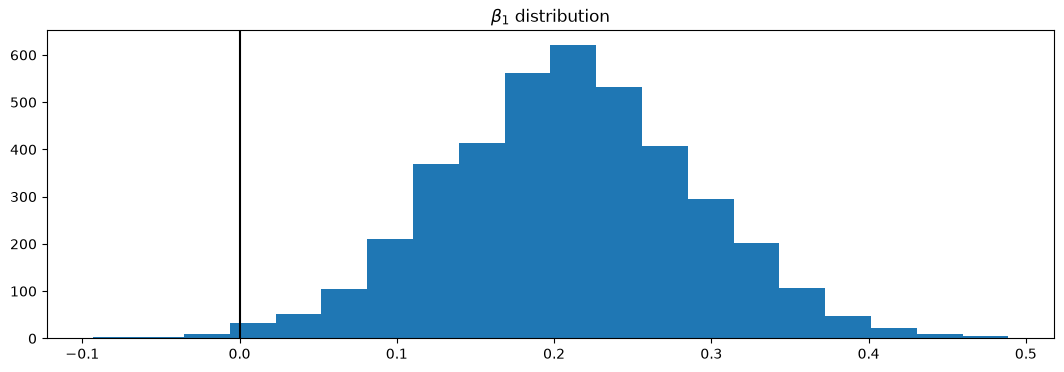

In [177]:
intervention_effect = idata.posterior['group']
effect_summary = data_summary(intervention_effect)
posterior_samples = intervention_effect.stack( sample=('chain', 'draw') )[0]

plt.figure(figsize=(13,4))
plt.axvline(0,color='black')
plt.hist(posterior_samples, bins=20)
plt.title(r'$\beta_1$ distribution')
print(f"P(beta1 <= 0 | data) = " f"{np.mean(posterior_samples <= 0):.3f}")

We obtain a small p-value (specifically < 5%) which is enough to reject the null hypothesis.